# 01 EDA (consumes `build_features()`, creates no features of its own)
Every feature used by the model comes from `speedy.features.build_features`. This notebook only *looks* at them, so execution order no longer matters.
Data path: `SPEEDY_DATA_DIR` env var, default `data/raw/`.

In [1]:
import sys, warnings; sys.path.insert(0, "../src"); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from speedy.config import DATA_DIR, MODEL_PATH
from speedy.data import load_panel, to_wide
from speedy.features import build_features, FEATURE_COLUMNS
print("data dir:", DATA_DIR)

data dir: /home/claude/data/Turing College Module 6/Speedy Forecasting


In [2]:
panel = load_panel(DATA_DIR)          # validated: rectangular, weekly, positive, no duplicates
feat = build_features(panel[["Store","Date","Type"]])
print(panel.shape, panel.Date.min().date(), "->", panel.Date.max().date(), "| stores:", panel.Store.nunique())
print("feature contract:", len(FEATURE_COLUMNS), "columns; NaN:", int(feat[FEATURE_COLUMNS].isna().sum().sum()))
feat.head(3)

(6435, 4) 2010-02-05 -> 2012-10-26 | stores: 45
feature contract: 32 columns; NaN: 0


,Store,Date,Type,s1,c1,s2,c2,s3,c3,s4,...,xm-2,xm-1,xm0,xm1,xm2,xm3,superbowl,laborday,easter,trend
0,1,2010-02-05,A,0.580455,0.814292,0.94532,0.326144,0.959079,-0.283139,0.616621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2010-02-05,A,0.580455,0.814292,0.94532,0.326144,0.959079,-0.283139,0.616621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2010-02-05,B,0.580455,0.814292,0.94532,0.326144,0.959079,-0.283139,0.616621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


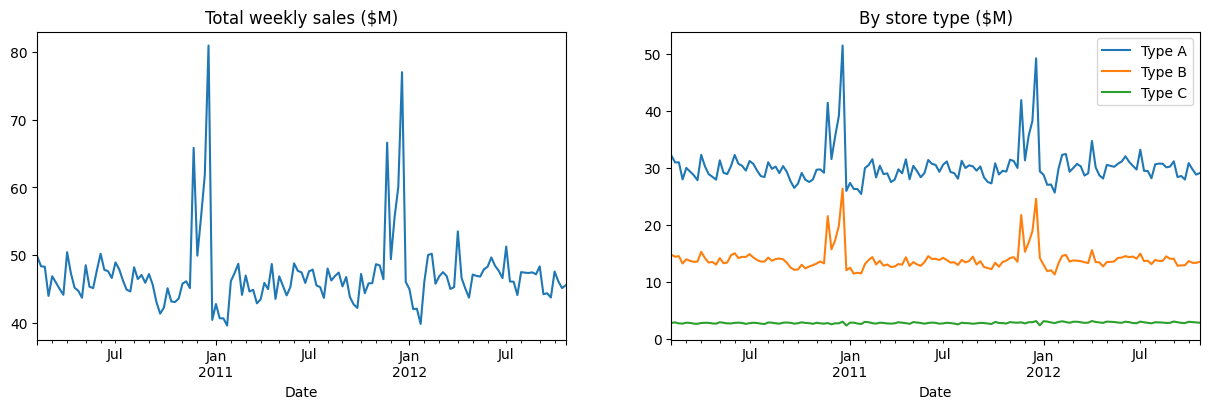

same 43 weeks YoY 2012 vs 2011: 0.025730435972376897


In [3]:
wide = to_wide(panel)
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
(wide.sum(axis=1)/1e6).plot(ax=ax[0], title="Total weekly sales ($M)")
for t, g in panel.groupby("Type"): (g.groupby("Date").Weekly_Sales.sum()/1e6).plot(ax=ax[1], label=f"Type {t}")
ax[1].legend(); ax[1].set_title("By store type ($M)"); plt.show()
print("same 43 weeks YoY 2012 vs 2011:", wide.sum(axis=1).loc["2012-01-06":"2012-10-26"].sum()/wide.sum(axis=1).loc["2011-01-07":"2011-10-28"].sum()-1)

## Do the holiday features capture what we see?
Average sales relative to each store's own mean, by week relative to Thanksgiving (`th*` features) and Christmas (`xm*`).

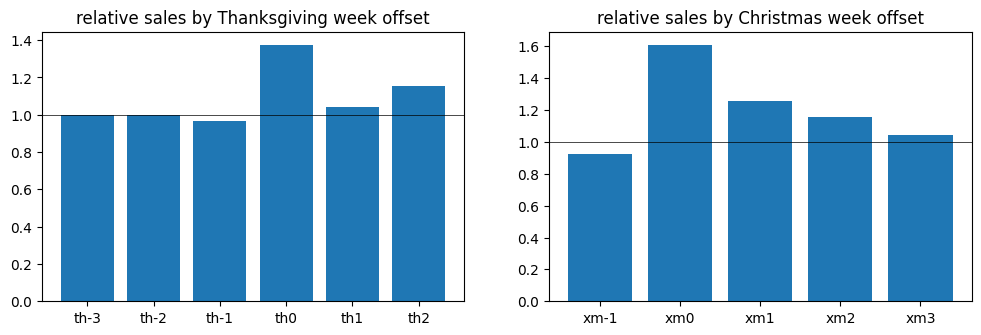

In [4]:
rel = (panel.assign(rel=panel.Weekly_Sales / panel.groupby("Store").Weekly_Sales.transform("mean")).merge(feat[["Store","Date"]+FEATURE_COLUMNS], on=["Store","Date"]))
th = {c: rel.loc[rel[c]==1, "rel"].mean() for c in [f"th{l}" for l in range(-3,3)]}; xm = {c: rel.loc[rel[c]==1, "rel"].mean() for c in [f"xm{l}" for l in range(-2,4)]}
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5)); ax[0].bar(th.keys(), th.values()); ax[0].axhline(1, c="k", lw=.5); ax[0].set_title("relative sales by Thanksgiving week offset")
ax[1].bar(xm.keys(), xm.values()); ax[1].axhline(1, c="k", lw=.5); ax[1].set_title("relative sales by Christmas week offset"); plt.show()

**Take-aways:** strong yearly seasonality with big Thanksgiving/Christmas weeks that move across calendar weeks (so naive 52-week lags need holiday re-alignment); flat-to-slightly-growing level; only ~2.7 years of history. Exogenous columns (Temperature, CPI, Fuel, MarkDowns) are deliberately not used: unknown for 2013 and MarkDowns exist only from Nov 2010.